In [1]:
# mport sqlite3: Yeh Python ki apni library hai jo aapko SQL database banane aur chalane ki ijazat deti hai. 
# Isse aap computer mein ek local database file bana sakte ho.

# import pandas as pd: Pandas data analysis ke liye sabse famous library hai

# sqlite3.connect(...): Yeh line computer mein supermarket.db naam ki ek nayi database
# file banati hai (agar pehle se nahi bani hui).

# conn: Yeh ek "Connection Object" hai, jo aapki Python script ko us database file se jor kar rakhta hai.


import sqlite3
import pandas as pd

# Create database and load data
conn = sqlite3.connect('supermarket.db')
df = pd.read_csv('SuperMarket Analysis.csv')

# df.to_sql(...): Yeh Pandas ka ek behtareen function hai jo DataFrame ke saare data ko direct SQL
# database mein bhej deta hai.

# conn: Yeh batata hai ki kis database (supermarket.db) mein data save karna hai.

# if_exists='replace': Agar 'sales' naam ka table pehle se wahan maujood hai, to usko delete karke
# naya bana do (takay duplicate data na ho).

# index=False: Pandas ke apne serial numbers (indexes) hote hain, yeh line unhe database mein table
# ka column banane se rokti hai.

df.to_sql('sales', conn, if_exists='replace', index=False)

# Basic queries

# pd.read_sql(...): Yeh SQL query ko database par chalata hai aur jo result aata hai, usko wapas ek
# Pandas DataFrame mein badal deta hai.



# "SELECT * FROM sales LIMIT 10":

# SELECT *: Iska matlab hai "Saare columns chuno".

# FROM sales: Iska matlab hai "sales naam ke table se".

# LIMIT 10: Iska matlab hai "Sirf pehli 10 rows (records) dikhao".

# print(q1): Yeh un 10 rows ko aapki screen par display kar deta hai.
q1 = pd.read_sql("SELECT * FROM sales LIMIT 10", conn)
print(q1)



q2 = pd.read_sql("""
    SELECT City, Branch, Sales, Rating
    FROM sales
    WHERE City = 'Yangon'
    ORDER BY Sales DESC
    LIMIT 5
""", conn)
print(q2)


    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   
5  699-14-3026   Giza  Naypyitaw        Member  Female   
6  355-53-5943   Alex     Yangon        Member  Female   
7  315-22-5665   Giza  Naypyitaw        Member  Female   
8  665-32-9167   Alex     Yangon        Member  Female   
9  692-92-5582  Cairo   Mandalay        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22

In [2]:
# GROUP BY queries — most common in DS interviews

# Jab hamare paas hazaron rows ka data hota hai aur hume uska summary (nichod) nikalna ho—jaise har shehar ki 
# total sale kitni hui—tab hum GROUP BY use karte hain.


# Revenue by city

# GROUP BY City: Iska matlab hai poore table ko shehron ke naam par baant do. Agar data mein 3 cities hain
# (Yangon, Mandalay, Naypyitaw), to yeh unke 3 alag-alag groups bana dega.


# SELECT City: Output mein shehar ka naam dikhao.

# SUM(Sales) AS total_revenue: Har shehar ke group ki saari sales ko aapas mein jama (add) karo, aur column
# ka naam rakh do total_revenue.


# COUNT(*) AS transactions: Is shehar mein total kitni baar shopping ki gayi (rows ki ginti), uska naam rakh do transactions.

# AVG(Sales) AS avg_transaction: Is shehar ki average (ausat) sale kitni rahi, naam rakh do avg_transaction.

# AVG(Rating) AS avg_rating: Is shehar ke logon ne average rating kya di, naam rakh do avg_rating.

# ORDER BY total_revenue DESC: Jis shehar se sabse zyada kamai (total_revenue) hui, use sabse upar dikhao (Highest to Lowest).
city_revenue = pd.read_sql("""
    SELECT City,
           SUM(Sales)   AS total_revenue,
           COUNT(*)     AS transactions,
           AVG(Sales)   AS avg_transaction,
           AVG(Rating)  AS avg_rating
    FROM sales
    GROUP BY City
    ORDER BY total_revenue DESC
""", conn)
print(city_revenue)

# HAVING: only cities with avg sales > 300

# GROUP BY City: Pehle ki tarah data ko shehron ke hisab se groups mein baant diya.

# SELECT City, AVG(Sales) AS avg_sales: Har shehar ka naam aur uski average sale nikaal li.

# HAVING AVG(Sales) > 300: Yeh sabse important line hai. Interviewer aksar puchte hain ki WHERE aur HAVING mein kya farq hai?

# WHERE tab lagta hai jab group banane se PEHLE single-single row ko filter karna ho.

# HAVING tab lagta hai jab GROUP BY ka kaam ho chuka ho, aur hume bane-banaye groups par shart lagani ho.

# Yeh line sirf un shehron ke groups ko bachaegi jinki average sale $300 se zyada hogi, baakiyon ko nikaal degi.
high_value = pd.read_sql("""
    SELECT City, AVG(Sales) AS avg_sales
    FROM sales
    GROUP BY City
    HAVING AVG(Sales) > 300
""", conn)
print(high_value)

# Multi-column groupby

# GROUP BY City, Gender: Yeh combo (jodi) ke hisab se group banayega. Jaise:

# Yangon - Male

# Yangon - Female

# Mandalay - Male

# Mandalay - Female

# SELECT City, Gender, SUM(Sales) AS revenue, COUNT(*) AS count: Har combo ke samne uska naam, gender, unki 
# total sales (revenue) aur unho ne kitni baar shopping ki (count) dikhao.

# ORDER BY City, revenue DESC: Pehle data ko City ke mutabiq ABC order mein set karo, aur phir har shehar ke 
# andar jis gender ne zyada kharidari ki (revenue DESC), use upar dikhao.

gender_city = pd.read_sql("""
    SELECT City, Gender,
           SUM(Sales) AS revenue,
           COUNT(*)   AS count
    FROM sales
    GROUP BY City, Gender
    ORDER BY City, revenue DESC
""", conn)
print(gender_city)

        City  total_revenue  transactions  avg_transaction  avg_rating
0  Naypyitaw    110568.7065           328       337.099715    7.072866
1     Yangon    106200.3705           340       312.354031    7.027059
2   Mandalay    106197.6720           332       319.872506    6.818072
        City   avg_sales
0   Mandalay  319.872506
1  Naypyitaw  337.099715
2     Yangon  312.354031
        City  Gender     revenue  count
0   Mandalay  Female  61210.0860    184
1   Mandalay    Male  44987.5860    148
2  Naypyitaw  Female  70183.9950    200
3  Naypyitaw    Male  40384.7115    128
4     Yangon  Female  63277.7565    187
5     Yangon    Male  42922.6140    153


In [3]:
# Jab hamare paas data alag-alag tables mein bikhra hua hota hai aur hume unhe aapas mein jodna ho, 
# tab hum JOIN use karte hain.




# Create a second table to practice JOINs

# product_line: Product ka naam (jo pehle wale sales table se match karta hai).

# category: Us product ki broad category (jaise Health and beauty ko 'Personal care' bol diya).

# margin_pct: Us product par kitne percent profit margin milta hai (e.g., 0.35 ka matlab 35% profit).

# pd.DataFrame(...): Is data ko ek naye table (DataFrame) mein convert kiya.

# to_sql('products', ...): Is naye table ko database mein products naam se save kar diya. Ab hamare 
# database mein do tables hain: sales aur products.


products_data = {
    'product_line': ['Health and beauty', 'Electronic accessories',
                    'Home and lifestyle', 'Sports and travel',
                    'Food and beverages', 'Fashion accessories'],
    'category':     ['Personal care', 'Tech', 'Home',
                    'Lifestyle', 'FMCG', 'Fashion'],
    'margin_pct':   [0.35, 0.22, 0.28, 0.31, 0.18, 0.40]
}
products_df = pd.DataFrame(products_data)
products_df.to_sql('products', conn, if_exists='replace', index=False)


# FROM sales s: Hum sales table se shuru kar rahe hain aur code ko chota rakhne ke liye isko ek short 
# naam s (alias) de rahe hain.

# INNER JOIN products p: Hum isko products table ke saath jod rahe hain aur is table ko short naam p de rahe 
# hain. INNER JOIN ka matlab hai sirf wahi rows aayengi jo dono tables mein match karengi.

# ON s.'Product line' = p.product_line: Yeh woh connection bridge (matching condition) hai. Iska matlab hai:

# sales table ke 'Product line' column ko products table ke product_line column se aapas mein match karo.

# SELECT ...: Ab hum dono tables ke columns select kar sakte hain:

# s.City, s.Sales, s.'Product line': Yeh columns hum sales table (s) se le rahe hain.

# p.category, p.margin_pct: Yeh columns hum products table (p) se le rahe hain.

# s.Sales * p.margin_pct AS estimated_profit: Hum sales ki raqam ko profit margin se multiply (guna) kar rahe
# hain takay pata chal sake kitna profit hua. Is naye column ka naam humne estimated_profit rakha.

# ORDER BY estimated_profit DESC LIMIT 10: Sabse zyada profit wale top 10 transactions ko upar se neeche 
# ke order mein print kar do.


# INNER JOIN
join_result = pd.read_sql("""
    SELECT s.City, s.Sales, s.'Product line',
           p.category, p.margin_pct,
           s.Sales * p.margin_pct AS estimated_profit
    FROM sales s
    INNER JOIN products p
        ON s.'Product line' = p.product_line
    ORDER BY estimated_profit DESC
    LIMIT 10
""", conn)
print(join_result)

# JOIN + GROUP BY: category revenue and avg margin


# Yeh query advanced level ki hai kyunki isme hum tables ko JOIN bhi kar rahe hain aur phir unhe GROUP BY karke unka 
# analysis bhi kar rahe hain.

# FROM sales s JOIN products p ON s.'Product line' = p.product_line: Pehle ki tarah humne dono tables ko matching values
# par aapas mein join kar liya.

# GROUP BY p.category: Ab hum saare transactions ko unki product category (Personal care, Tech, Home etc.) ke hisab se 
# groups mein baant rahe hain.

# SELECT p.category: Output mein category ka naam dikhao.

# SUM(s.Sales) AS total_revenue: Har category mein total kitni sales hui, unka sum nikal kar column ka naam total_revenue rakh diya.

# AVG(p.margin_pct) AS avg_margin: Us category ka average profit margin kya tha, column ka naam avg_margin rakha.

# SUM(s.Sales * p.margin_pct) AS est_profit: Pehle har transaction ka profit nikala (Sales * margin_pct) aur phir us category
# ke saare profits ko jama (SUM) kar diya takay us category ka kul profit (est_profit) pata chal sake.

# ORDER BY est_profit DESC: Jis category ne sabse zyada profit (est_profit) kamakar diya, use sabse upar dikhao.


category_analysis = pd.read_sql("""
    SELECT p.category,
           SUM(s.Sales)       AS total_revenue,
           AVG(p.margin_pct)  AS avg_margin,
           SUM(s.Sales * p.margin_pct) AS est_profit
    FROM sales s
    JOIN products p ON s.'Product line' = p.product_line
    GROUP BY p.category
    ORDER BY est_profit DESC
""", conn)
print(category_analysis)

        City     Sales         Product line       category  margin_pct  \
0  Naypyitaw  1042.650  Fashion accessories        Fashion        0.40   
1     Yangon  1039.290  Fashion accessories        Fashion        0.40   
2  Naypyitaw  1020.705  Fashion accessories        Fashion        0.40   
3  Naypyitaw   943.299  Fashion accessories        Fashion        0.40   
4   Mandalay   874.125  Fashion accessories        Fashion        0.40   
5  Naypyitaw   867.615  Fashion accessories        Fashion        0.40   
6  Naypyitaw   950.250    Health and beauty  Personal care        0.35   
7  Naypyitaw   829.080  Fashion accessories        Fashion        0.40   
8     Yangon   817.236  Fashion accessories        Fashion        0.40   
9   Mandalay   922.635    Health and beauty  Personal care        0.35   

   estimated_profit  
0         417.06000  
1         415.71600  
2         408.28200  
3         377.31960  
4         349.65000  
5         347.04600  
6         332.58750  
7        

=== SALES TIERS ===
sales_tier
Low Value       410
Medium Value    363
High Value      227
Name: count, dtype: int64


=== MONTHLY REVENUE ===
     month     revenue  transactions  avg_rating
0  2019-01  116291.868           352    7.017614
1  2019-02   97219.374           303    7.071287
2  2019-03  109455.507           345    6.840290


Graph 'monthly_revenue.png' ke naam se save ho gaya hai!


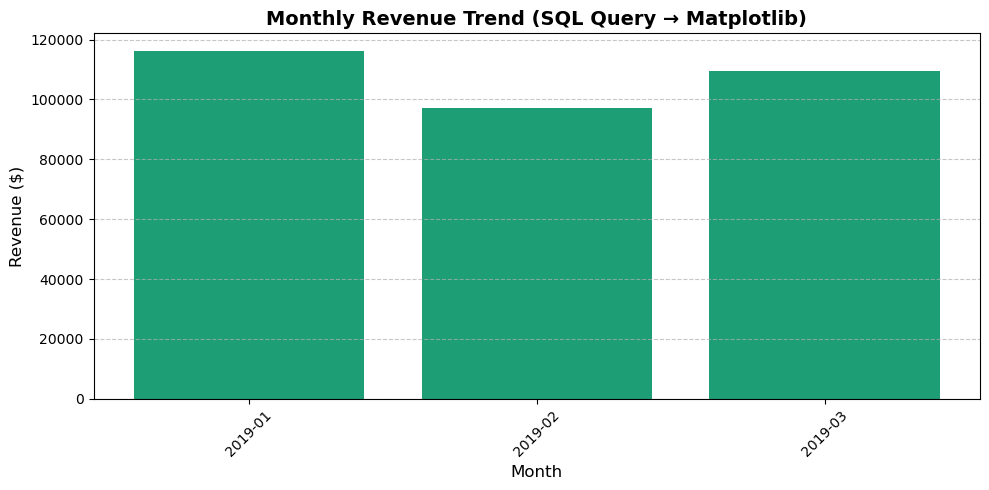

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Database se connection banana aur Data Load karna


# Humne supermarket.db se connection banaya aur Pandas ke zariye original CSV file ka data df variable mein load kar liya.
conn = sqlite3.connect('supermarket.db')
df = pd.read_csv('SuperMarket Analysis.csv')


# Data cleaning: Date column ko proper format mein convert karna


# pd.to_datetime(...): Yeh bohot important line hai. CSV file mein dates kabhi kabhi text (string) format mein hoti
# hain jise SQL sahi se samajh nahi pata. Yeh command unhe real Date format mein convert karti hai.


# .dt.strftime('%Y-%m-%d'): Yeh saari dates ko ek standard format deti hai: Saal-Mahina-Din (e.g., 2019-01-25). Isse 
# SQL ke date functions (jaise strftime) bilkul sahi kaam karte hain.

# df.to_sql(...): Is saaf-suthre data ko humne SQL ke 'sales' table mein save kar diya.


df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')
df.to_sql('sales', conn, if_exists='replace', index=False)


# -------------------------------------------------------------
# 2. Products table banana (JOINs ki practice ke liye)
# -------------------------------------------------------------



# ahan humne Python ke andar hi ek chota sa data (products_data) banaya aur use database mein ek naye table
# products ke naam se save kar diya. Iska maqsad aage chal kar tables ko aapas mein jorna (JOIN karna) hai.

# CASE WHEN ...: Yeh SQL ka if-else hai.

# Agar Sales 500 se zyada hain, to use 'High Value' ka tag de do.

# Agar Sales 200 se zyada hain, to use 'Medium Value' ka tag de do.

# Baaki sab ko 'Low Value' bol do

# END AS sales_tier: Is poori condition se jo naya column banega, uska naam sales_tier rakh do.


products_data = {
    'product_line': ['Health and beauty', 'Electronic accessories',
                     'Home and lifestyle', 'Sports and travel',
                     'Food and beverages', 'Fashion accessories'],
    'category':     ['Personal care', 'Tech', 'Home',
                     'Lifestyle', 'FMCG', 'Fashion'],
    'margin_pct':   [0.35, 0.22, 0.28, 0.31, 0.18, 0.40]
}
products_df = pd.DataFrame(products_data)
products_df.to_sql('products', conn, if_exists='replace', index=False)

# -------------------------------------------------------------
# 3. CASE WHEN Query (Sales Tiers)
# -------------------------------------------------------------
tiered = pd.read_sql("""
    SELECT Sales, City, 'Product line',
           CASE
               WHEN Sales > 500 THEN 'High Value'
               WHEN Sales > 200 THEN 'Medium Value'
               ELSE 'Low Value'
           END AS sales_tier
    FROM sales
    ORDER BY Sales DESC
""", conn)


# value_counts(): Yeh Pandas ka function hai jo ginte hain ki 'High Value', 'Medium Value', aur 'Low Value' wale
# kitne transactions hain aur unka total count screen par show karta hai.


print("=== SALES TIERS ===")
print(tiered['sales_tier'].value_counts())
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------
# 4. Monthly Revenue Query (Error-free version)
# -------------------------------------------------------------


# strftime('%Y-%m', Date) AS month: Yeh har transaction ki date (jaise 2019-01-25) mein se din ko hata kar 
# sirf Saal aur Mahina (2019-01) nikaal leta hai aur use month ka naam de deta hai.

# WHERE Date IS NOT NULL AND Date != '': Yeh check karta hai ki koi date khali ya ghalat na ho. Khali data
# ko pehle hi filter kar deta hai takay aage chal kar Matplotlib crash na kare.


# GROUP BY month: Poore data ko mahinon ke hisab se group kar deta hai (jaise January ka alag, February ka alag).

# ORDER BY month: Data ko purane mahine se naye mahine ke sequence mein set karta hai (e.g., Jan -> Feb -> Mar).


monthly = pd.read_sql("""
    SELECT strftime('%Y-%m', Date) AS month,
           SUM(Sales)              AS revenue,
           COUNT(*)                AS transactions,
           AVG(Rating)             AS avg_rating
    FROM sales
    WHERE Date IS NOT NULL AND Date != ''  -- Khali dates ko filter kiya
    GROUP BY month
    ORDER BY month
""", conn)

print("=== MONTHLY REVENUE ===")
print(monthly)
print("\n" + "="*50 + "\n")

# -------------------------------------------------------------
# 5. Matplotlib Visualization (Bina kisi error ke plot karega)
# -------------------------------------------------------------
plt.figure(figsize=(10, 5))

# .astype(str) lagaya takay Matplotlib data type ki wajah se error na de





# plt.bar(...): Yeh ek Bar Chart (dande wala graph) banata hai.

# monthly['month'].astype(str): Yeh wahi fix hai jo aapke error ko solve karta hai. Humne month column ke data 
# ko zabardasti string (text) mein badal diya, takay Matplotlib bina nakhre ke use X-axis par plot kar de.

# monthly['revenue']: Yeh Y-axis par dikhayega ki kis mahine kitni kamai (revenue) hui.

# color='#1D9E75': Yeh bars ko ek khoobsurat emerald-green color deta hai.



plt.bar(monthly['month'].astype(str), monthly['revenue'], color='#1D9E75')


# plt.title / xlabel / ylabel: Graph ka heading aur X/Y axis ke labels set karte hain.

# plt.xticks(rotation=45): X-axis par likhe mahinon ke naam (2019-01, 2019-02) ko thoda tilda (45 degrees) ghuma deta
# hai takay woh aapas mein takrayen nahi aur aasani se parhe ja saken.

plt.title('Monthly Revenue Trend (SQL Query → Matplotlib)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)


# plt.grid(...): Peeche halki-halki dash lines banata hai takay andaza lagana aasan ho ki bar ki height kitni hai.

# plt.tight_layout(): Graph ke margins ko automatic fit karta hai takay koi text screen se baahar na kat jaye.

plt.grid(axis='y', linestyle='--', alpha=0.7)  # Graph ko behtar dikhane ke liye grid lines
plt.tight_layout()

# Graph save aur show karna


# plt.savefig(...): Graph ko computer mein high-quality photo (dpi=200) ke taur par save kar deta hai.

# plt.show(): Graph ko aapki screen par pop-up window mein display karta hai.

# conn.close(): Jab saara kaam khatam ho jaye, to database se connection ka band karna behtareen coding practice hai.


plt.savefig('monthly_revenue.png', dpi=200)
print("Graph 'monthly_revenue.png' ke naam se save ho gaya hai!")
plt.show()

# Connection close karna
conn.close()